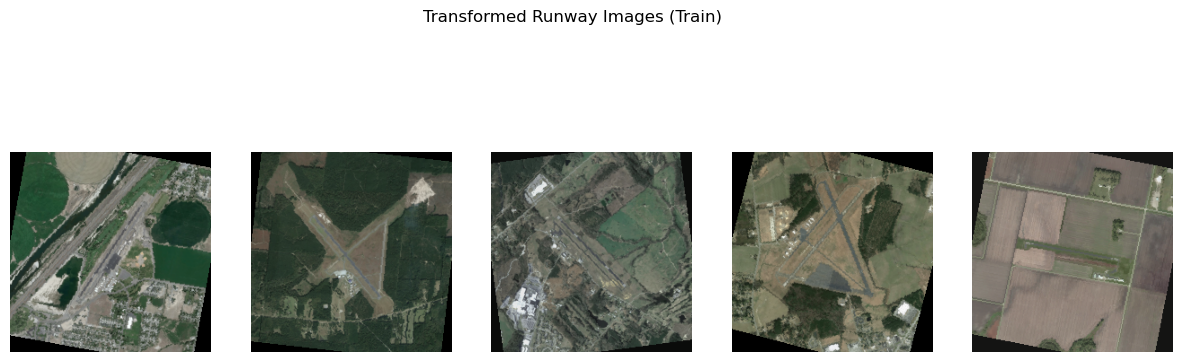

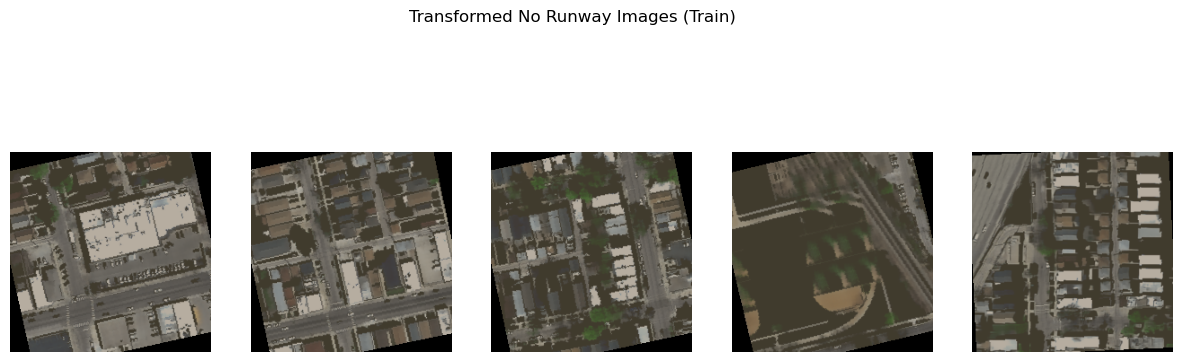

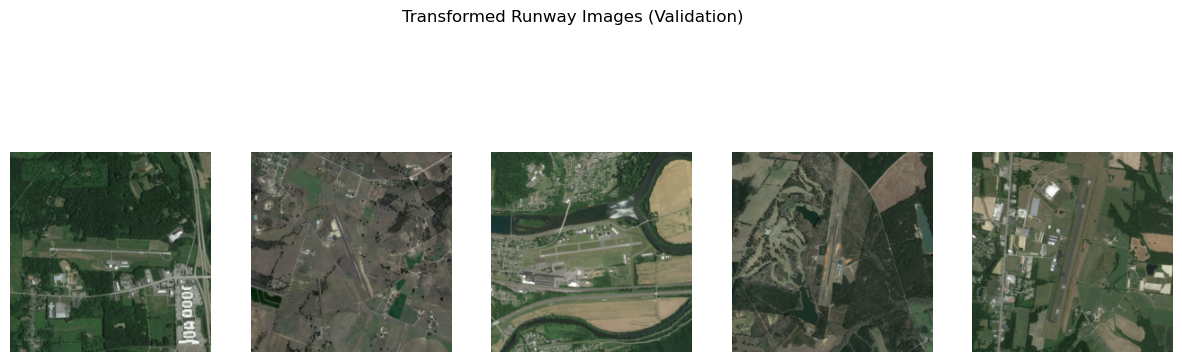

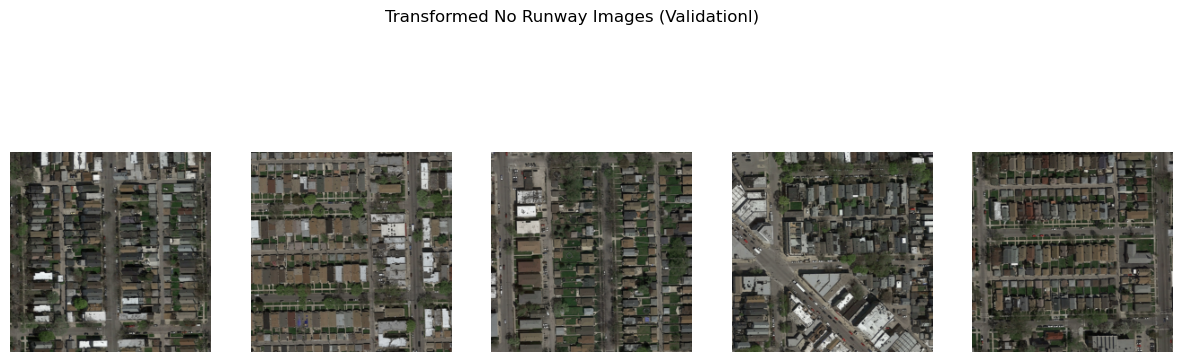

In [1]:
from PIL import Image
import os
import sys
import random
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

sys.path.append('/Users/varundhingra/Desktop/runway_classification/scripts/data_utils')
from data_transforms import train_transforms, validate_transforms  # Import both

train_directory = "../data/TrainSet"
val_directory = "../data/ValidationSet"

# 5 random images
runway_files = random.sample(os.listdir(os.path.join(train_directory, 'runway')), 5)
no_runway_files = random.sample(os.listdir(os.path.join(train_directory, 'no_runway')), 5)
runway_images = [os.path.join(train_directory, 'runway', f) for f in runway_files]
no_runway_images = [os.path.join(train_directory, 'no_runway', f) for f in no_runway_files]
val_runway_files = random.sample(os.listdir(os.path.join(val_directory, "runway")), 5)
val_no_runway_files = random.sample(os.listdir(os.path.join(val_directory, "no_runway")), 5)
val_runway_images = [os.path.join(val_directory, "runway", f) for f in val_runway_files]
val_no_runway_images = [os.path.join(val_directory, "no_runway", f) for f in val_no_runway_files]

def apply_transforms(image_paths, transform):
    transformed_images = []
    for path in image_paths:
        image = Image.open(path).convert('RGB')
        transformed_image = transform(image)
        transformed_images.append(transformed_image)
    return transformed_images

transformed_runway_images_train = apply_transforms(runway_images, train_transforms)
transformed_no_runway_images_train = apply_transforms(no_runway_images, train_transforms)
transformed_runway_images_val = apply_transforms(val_runway_images, validate_transforms)
transformed_no_runway_images_val = apply_transforms(val_no_runway_images, validate_transforms)

# Displaying the transformed images

def display_images(transformed_images, title):
    # Denormalize for display (inverse of Normalize in transforms)
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    # Randomly select 5 images from the list
    selected_images = random.sample(transformed_images, 5)
    
    plt.figure(figsize=(15, 5))
    for i, img in enumerate(selected_images):
        plt.subplot(1, 5, i + 1)
        img_denorm = inv_normalize(img).clamp(0, 1)  # Denormalize and clamp to [0,1]
        img_np = img_denorm.permute(1, 2, 0).numpy()
        plt.imshow(img_np)
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

display_images(transformed_runway_images_train, "Transformed Runway Images (Train)")
display_images(transformed_no_runway_images_train, "Transformed No Runway Images (Train)")
display_images(transformed_runway_images_val, "Transformed Runway Images (Validation)")
display_images(transformed_no_runway_images_val, "Transformed No Runway Images (Validationl)")

In [ ]:
import torch